# ML Week 20: Masked AutoEncoders (MAE)

Last week we saw how AutoEncoders can be excellent tools for generating powerful "embedding vectors" of data.
In the case of a Convolutional AutoEncoder (CAE) this is done by convolving down to a very small "bottleneck" layer, and then devonvolving back up to reconstructed data. Once the AE gets good at reconstruction, we can infer that the small bottleneck layer is nicely capturing the "essence" of the data. This "essence" (the embedding vector) can then be created by only using the first half of the CAE (the encoder) and applied to many different ML algorithms, some of which we learned last semester (clustering, random forest, isolation forest, etc.).

Today we will discuss another superpower of AutoEncoders: their ability to reconstruct data.

Last week we used a ResNet18 as the encoder portion of our network. Today we will use Meta's powerful Vision Transformer (ViT), again with pre-trained weights.

Although still based on convolutions*, this encoder is quite different from ResNet18. The image it receives is broken up into 16x16 pixel "patches". These are then handled by transformer blocks.

<sup><sup> \* Note: The original ViT had no convolutions. Patches were simply "unraveled" into 1D vectors. But some small convolutional layers (applied individually to each patch) were found to work better, and this is now the standard. </sup></sup>

### Masking Patches

Last week we saw how CAEs are trained by trying to reconstruct images. In 2021 it was realized that, to push them even harder to learn reconstruction, we can mask some of the patches so they only have limited input. Yet they must still reconstruct the entire image. This is known as a Masked AutoEncoder (MAE).

<img src="https://user-images.githubusercontent.com/11435359/146857310-f258c86c-fde6-48e8-9cee-badd2b21bd2c.png" width="600" class="center"/>

* ViT Paper: https://arxiv.org/abs/2111.06377
* Masked AutoEncoder Paper: https://arxiv.org/abs/2010.11929
* Original repo (on which this notebook is based): https://github.com/facebookresearch/mae
* Video explaining the paper: https://www.youtube.com/watch?v=Dp6iICL2dVI

### Getting Started

In [ ]:
# Install Transformers Library

%pip install -q git+https://github.com/huggingface/transformers.git

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [22]:
# For some people this may be necessary to download the model from Hugging Face

import os

os.environ["HF_HUB_DISABLE_XET"] = "1"

### Running an Image through the MAE

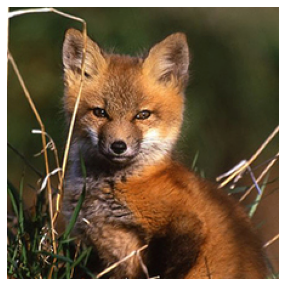

In [122]:
from PIL import Image

image = Image.open("./fox.png").convert("RGB")
image

In [123]:
from transformers import ViTImageProcessor

feature_extractor = ViTImageProcessor.from_pretrained("facebook/vit-mae-base")

fox_tensor = feature_extractor(image, return_tensors="pt").pixel_values

In [108]:
import torch
import numpy as np
import matplotlib.pyplot as plt

imagenet_mean = np.array(feature_extractor.image_mean)
imagenet_std = np.array(feature_extractor.image_std)

def show_tensor_image(tensor, title=''):
    assert tensor.shape[1] == 3
    # tensor is [N, 3, H, W]
    image = torch.einsum('nchw->hwc', tensor).detach().cpu()
    # image now is [H, W, 3]
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return


C:\Users\re72fam\AppData\Local\Temp\ipykernel_39104\905495275.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


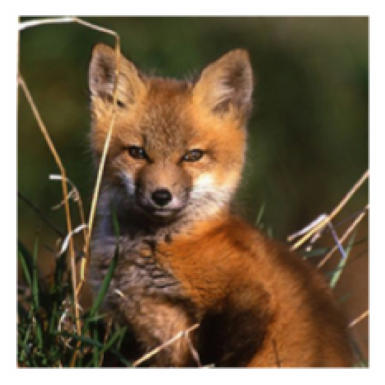

In [124]:
plt.figure(figsize=(8, 6), dpi=80)
show_tensor_image(fox_tensor)

Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

C:\Users\re72fam\AppData\Local\Temp\ipykernel_39104\905495275.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


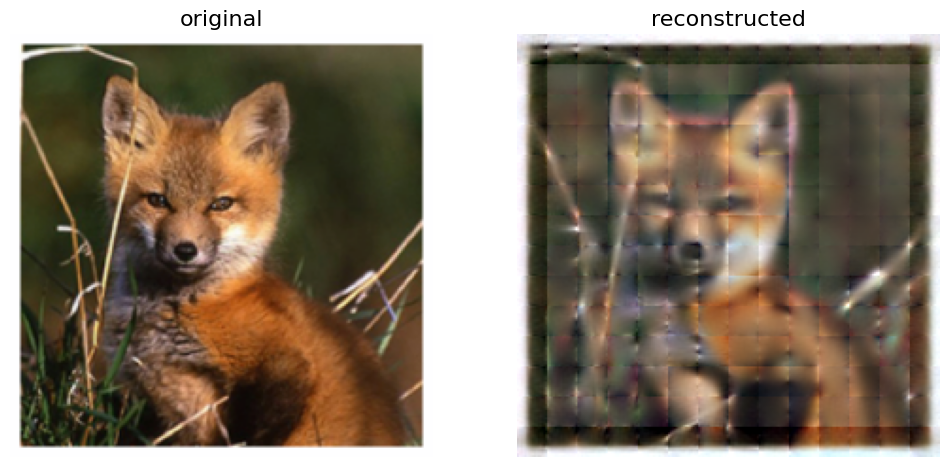

In [126]:
from transformers import ViTMAEForPreTraining
model = ViTMAEForPreTraining.from_pretrained("facebook/vit-mae-base")

model.config.mask_ratio = 0.0
outputs = model(fox_tensor)
y = model.unpatchify(outputs.logits)

plt.rcParams['figure.figsize'] = [12, 12]

plt.subplot(1, 2, 1)
show_tensor_image(fox_tensor, "original")

plt.subplot(1, 2, 2)
show_tensor_image(y, "reconstructed")

plt.show()

#### Trying with something a little more niche

C:\Users\re72fam\AppData\Local\Temp\ipykernel_39104\905495275.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


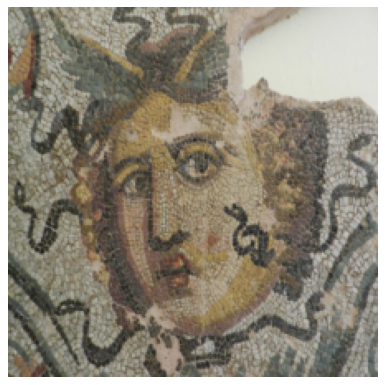

In [127]:
image = Image.open("./val_mosaic.jpg").convert('RGB')
mosaic_tensor = feature_extractor(image, return_tensors="pt").pixel_values

plt.figure(figsize=(8, 6), dpi=80)
show_tensor_image(mosaic_tensor)

C:\Users\re72fam\AppData\Local\Temp\ipykernel_39104\905495275.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


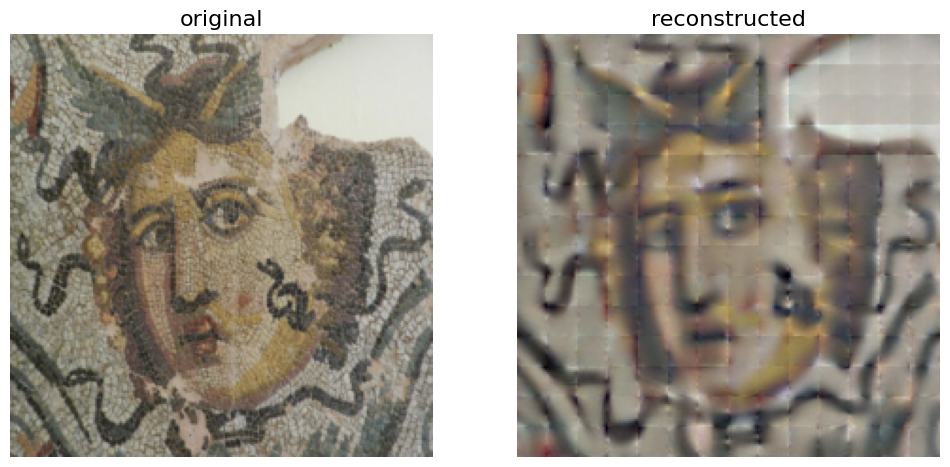

In [119]:
model.config.mask_ratio = 0.0
outputs = model(pixel_values)
y = model.unpatchify(outputs.logits)

plt.rcParams['figure.figsize'] = [12, 12]

plt.subplot(1, 2, 1)
show_tensor_image(pixel_values, "original")

plt.subplot(1, 2, 2)
show_tensor_image(y, "reconstructed")

plt.show()

### Masking

Let's see how masking works on a single image

C:\Users\re72fam\AppData\Local\Temp\ipykernel_39104\905495275.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


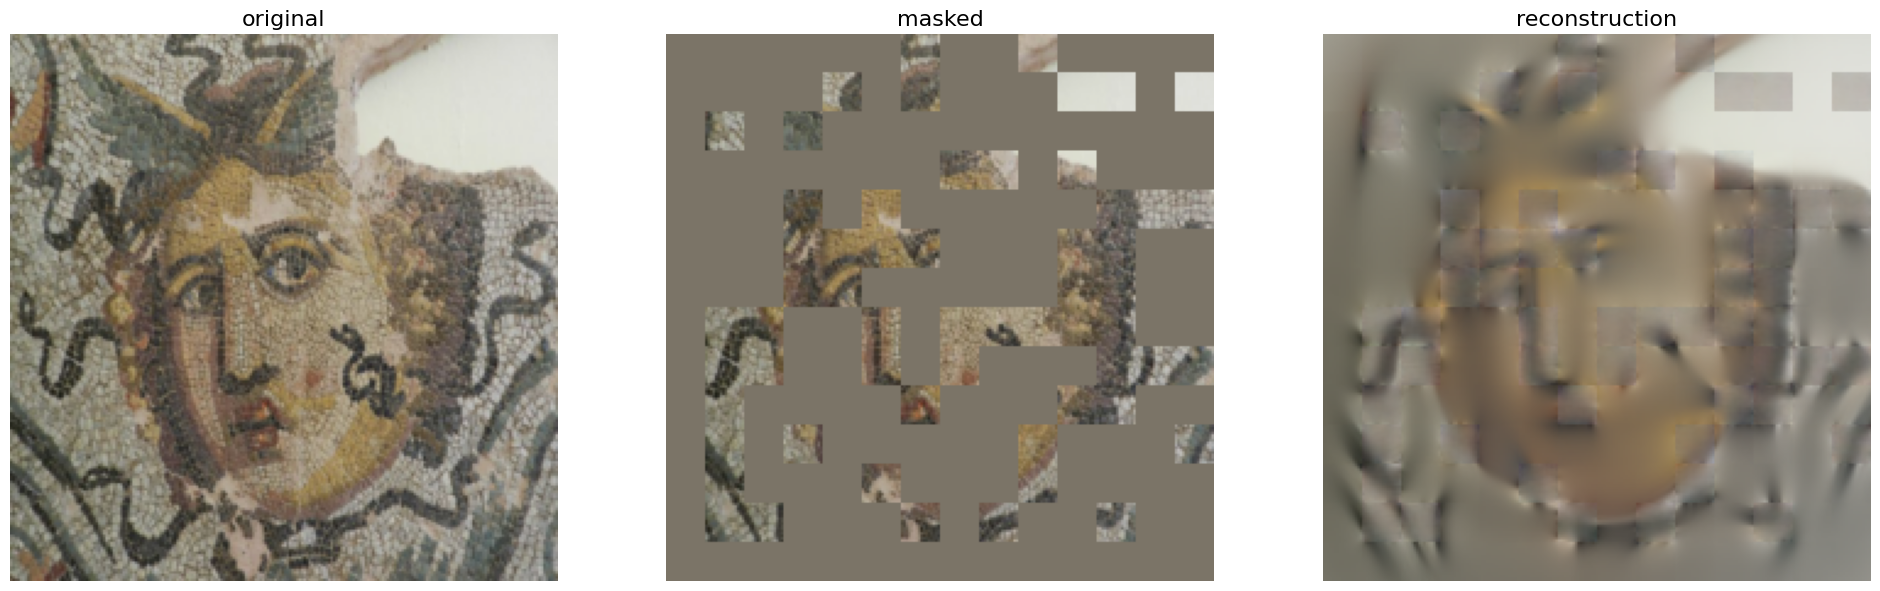

In [137]:
torch.manual_seed(42)

model.config.mask_ratio = 0.7
outputs = model(mosaic_tensor)
y = model.unpatchify(outputs.logits)

# visualize the mask
mask = outputs.mask.detach()
mask = mask.unsqueeze(-1).repeat(1, 1, model.config.patch_size**2 *3)  # (N, H*W, p*p*3)
mask = model.unpatchify(mask)  # 1 is removing, 0 is keeping

# masked image
im_masked = mosaic_tensor * (1 - mask)

# make the plt figure larger
plt.rcParams['figure.figsize'] = [24, 24]

plt.subplot(1, 3, 1)
show_tensor_image(mosaic_tensor, "original")

plt.subplot(1, 3, 2)
show_tensor_image(im_masked, "masked")

plt.subplot(1, 3, 3)
show_tensor_image(y, "reconstruction")

plt.show()

### Training

Now we will train over all of our mosaic images

In [11]:
from datasets import load_dataset

In [ ]:
# Load the dataset
dataset = load_dataset("../week19/mosaics/")
# Load the processor
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

def transform(example_batch):
    # Take a list of images and turn them into pixel values the model understands
    inputs = [x.convert('RGB') for x in example_batch['image']]
    inputs = processor(inputs, return_tensors='pt')
    #inputs['labels'] = example_batch['label']
    return inputs

# Apply the transformation to the dataset
prepared_ds = dataset.with_transform(transform)

Resolving data files:   0%|          | 0/234 [00:00<?, ?it/s]

In [33]:
prepared_ds

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 95
    })
})

In [13]:
from transformers import TrainingArguments, Trainer, ViTMAEForPreTraining

In [14]:
model = model.to('cpu')

In [16]:
training_args = TrainingArguments(
    output_dir="./mae-ad",
    label_names=["pixel_values"],
    per_device_train_batch_size=16,
    num_train_epochs=50,
    learning_rate=1e-4,
    do_eval=False,
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds['train']
)

trainer.train()
trainer.save_model()

Step,Training Loss
500,0.050049


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [17]:
trained_model = ViTMAEForPreTraining.from_pretrained("./mae-ad")

Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

In [18]:
trained_model

ViTMAEForPreTraining(
  (vit): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (layers): ModuleList(
      (0-11): 12 x ViTMAELayer(
        (attention): ViTMAEAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMAEMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        

In [19]:
torch.manual_seed(2)
visualize(pixel_values, model)

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

C:\Users\re72fam\AppData\Local\Temp\ipykernel_39104\3274277941.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


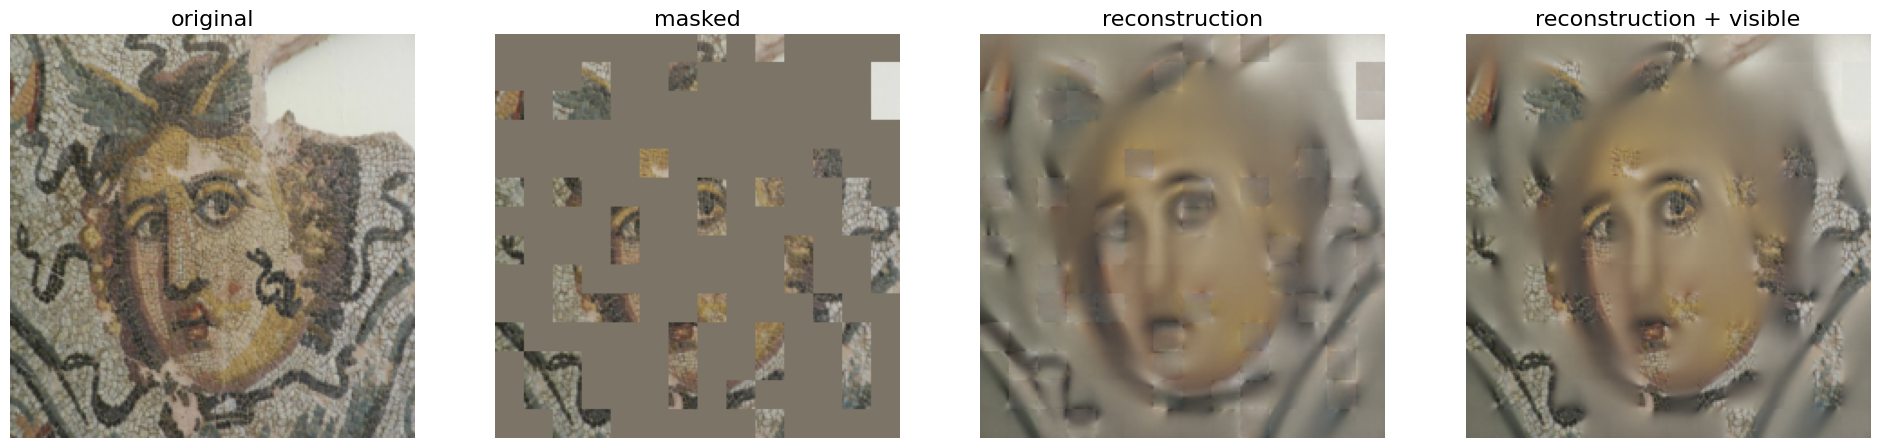

In [20]:
torch.manual_seed(2)
visualize(pixel_values, trained_model)

In [108]:
embedder = model.vit

In [110]:
embeddings, _, _ = embedder.to('cpu').embeddings(pixel_values)

In [111]:
embeddings.shape

torch.Size([1, 50, 768])

In [ ]:
outputs = model.to('cpu')(pixel_values)
y = model.unpatchify(outputs.logits)
y = torch.einsum('nchw->nhwc', y).detach().cpu()

## After pre-training

Note that, after pre-training, you can directly load the weights of the encoder into a `ViTForImageClassification` and start fine-tuning/doing linear probing. Note that a warning will be printed, indicating that the weights of the decoder aren't used.

In [6]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained("facebook/vit-mae-base")

You are using a model of type vit_mae to instantiate a model of type vit. This is not supported for all configurations of models and can yield errors.
Some weights of the model checkpoint at facebook/vit-mae-base were not used when initializing ViTForImageClassification: ['decoder.decoder_layers.0.attention.attention.value.weight', 'decoder.decoder_layers.3.output.dense.bias', 'decoder.decoder_layers.5.intermediate.dense.bias', 'decoder.decoder_layers.5.attention.attention.key.weight', 'decoder.decoder_layers.3.attention.attention.key.weight', 'decoder.decoder_layers.4.intermediate.dense.weight', 'decoder.decoder_layers.0.layernorm_before.bias', 'decoder.decoder_layers.1.layernorm_before.bias', 'decoder.decoder_layers.1.attention.attention.key.bias', 'decoder.decoder_layers.2.attention.attention.key.bias', 'decoder.decoder_layers.5.attention.attention.query.bias', 'decoder.decoder_layers.7.layernorm_after.weight', 'decoder.decoder_layers.5.attention.attention.value.weight', 'decoder.de